In [253]:
# Install necessary libraries
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Algerian Forest Fires - Regression Analysis

This notebook performs a regression analysis on the Algerian Forest Fires dataset to predict the Fire Weather Index (FWI). The analysis includes data cleaning, exploratory data analysis (EDA), and feature engineering. The final goal is to build a regression model to predict the FWI.
***
## Table of Contents
1.  [Import Libraries](#import-libraries)
2.  [Data Loading and Initial Exploration](#data-loading-and-initial-exploration)
3.  [Data Cleaning](#data-cleaning)
4.  [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)
5.  [Observations from EDA](#observations-from-eda)
6.  [Model Preparation](#model-preparation-and-training)
***
<a id="import-libraries"></a>
## 1. Import Libraries

In [254]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

<a id="data-loading-and-initial-exploration"></a>
## 2. Data Loading and Initial Exploration

In [255]:
# Load the dataset
dataset = pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv',header=1)

In [256]:
# Display the first few rows of the dataset
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [257]:
# Get information about the dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          246 non-null    str  
 1   month        245 non-null    str  
 2   year         245 non-null    str  
 3   Temperature  245 non-null    str  
 4    RH          245 non-null    str  
 5    Ws          245 non-null    str  
 6   Rain         245 non-null    str  
 7   FFMC         245 non-null    str  
 8   DMC          245 non-null    str  
 9   DC           245 non-null    str  
 10  ISI          245 non-null    str  
 11  BUI          245 non-null    str  
 12  FWI          245 non-null    str  
 13  Classes      244 non-null    str  
dtypes: str(14)
memory usage: 27.0 KB


<a id="data-cleaning"></a>
## 3. Data Cleaning

### 3.1. Checking for Missing Values

In [258]:
# Check for the sum of null values in each column
dataset.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
dtype: int64

In [259]:
# Check if any column has null values
dataset.isnull().any()

day            False
month           True
year            True
Temperature     True
 RH             True
 Ws             True
Rain            True
FFMC            True
DMC             True
DC              True
ISI             True
BUI             True
FWI             True
Classes         True
dtype: bool

In [260]:
# Display rows with any null values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


### 3.2. Adding a 'Region' Column

The dataset is divided into two regions: Bejaia and Sidi-Bel Abbes. We will add a 'Region' column to distinguish between them.
- **0**: Bejaia Region
- **1**: Sidi-Bel Abbes Region

In [261]:
# Assign region codes
dataset.loc[:122, 'Region'] = 0
dataset.loc[122:, 'Region'] = 1

In [262]:
# Display the first few rows with the new 'Region' column
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [263]:
# Get information about the dataset again to see the new column
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          246 non-null    str    
 1   month        245 non-null    str    
 2   year         245 non-null    str    
 3   Temperature  245 non-null    str    
 4    RH          245 non-null    str    
 5    Ws          245 non-null    str    
 6   Rain         245 non-null    str    
 7   FFMC         245 non-null    str    
 8   DMC          245 non-null    str    
 9   DC           245 non-null    str    
 10  ISI          245 non-null    str    
 11  BUI          245 non-null    str    
 12  FWI          245 non-null    str    
 13  Classes      244 non-null    str    
 14  Region       246 non-null    float64
dtypes: float64(1), str(14)
memory usage: 29.0 KB


In [264]:
# Convert the 'Region' column to integer type
dataset[['Region']] = dataset[['Region']].astype('int')

In [265]:
# Create a copy of the dataset for cleaning
df = dataset.copy()

In [266]:
# Display the first few rows of the new DataFrame
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [267]:
# Check for null values in the new DataFrame
df.isnull().sum()

day            0
month          1
year           1
Temperature    1
 RH            1
 Ws            1
Rain           1
FFMC           1
DMC            1
DC             1
ISI            1
BUI            1
FWI            1
Classes        2
Region         0
dtype: int64

### 3.3. Removing Null Values

In [268]:
# Drop rows with null values
df.dropna(inplace=True)
# Reset the index
df.reset_index(drop = True, inplace=True)

In [269]:
# Display the first few rows after dropping null values
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [270]:
# Check for null values again to confirm
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
 RH            0
 Ws            0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [271]:
# Display the row at index 122
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,1


In [272]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

### 3.4. Removing the 122nd Row

The row at index 122 contains headers and needs to be removed.

In [273]:
# Drop the row at index 122
df.drop(df.index[122], inplace=True)

In [274]:
# Display the row at index 122 again to confirm it's gone
df.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
123,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [275]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  ', 'Region'],
      dtype='str')

### 3.5. Fixing Spaces in Column Names

In [276]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

In [277]:
# Display the column names again to confirm
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [278]:
# Get information about the dataset to check data types
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    str  
 2   year         243 non-null    str  
 3   Temperature  243 non-null    str  
 4   RH           243 non-null    str  
 5   Ws           243 non-null    str  
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(1), str(14)
memory usage: 30.4 KB


### 3.6. Converting Columns to Integer Data Type

In [279]:
# Display the column names
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [280]:
# Display the first few rows
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [281]:
# Convert specified columns to integer type
df[['day','month','year','Temperature','RH','Ws']] = df[['day','month','year','Temperature','RH','Ws']].astype('int')

In [282]:
# Get information about the dataset to confirm the changes
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 30.4 KB


In [283]:
# Display the first few rows to see the changes
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 3.7. Converting Columns to Float Data Type

In [284]:
# Get a list of string-type features
features = [feature for feature in df.columns if df[feature].dtype == 'O']

In [285]:
# Convert string-type features (except 'Classes') to float
for i in features:
    if i!='Classes':
        df[i] = df[i].astype('float')

In [286]:
# Get information about the dataset to confirm the changes
df.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    int64
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(7), str(8)
memory usage: 30.4 KB


In [287]:
# Display the list of string-type features
features

[]

In [288]:
# Display descriptive statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,243.0,15.761317,8.842552,1.0,8.0,16.0,23.0,31.0
month,243.0,7.502058,1.114793,6.0,7.0,8.0,8.0,9.0
year,243.0,2012.000000,0.000000,2012.0,2012.0,2012.0,2012.0,2012.0
Temperature,243.0,32.152263,3.628039,22.0,30.0,32.0,35.0,42.0
RH,243.0,62.041152,14.828160,21.0,52.5,63.0,73.5,90.0
Ws,243.0,15.493827,2.811385,6.0,14.0,15.0,17.0,29.0
Region,243.0,0.497942,0.501028,0.0,0.0,0.0,1.0,1.0


In [289]:
# Display the first few rows of the cleaned dataset
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 3.8. Saving the Cleaned Dataset

The cleaned dataset is saved to a separate CSV file so the modeling steps can reuse a stable, preprocessed version of the data.

In [290]:
# Save the cleaned dataset to a new CSV file
df.to_csv('Algerian_forest_fires_cleaned_dataset.csv', index=False)

<a id="exploratory-data-analysis-eda"></a>
## 4. Exploratory Data Analysis (EDA)

### 4.1. Dropping Date Columns for EDA

In [291]:
# Create a copy of the original DataFrame before dropping columns
df_original = df.copy()

In [292]:
# Drop date-related columns for EDA
df.drop(['day','month','year'], axis=1, inplace=True)

In [293]:
# Display the first few rows after dropping columns
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


### 4.2. Checking Categories in 'Classes' Column

In [294]:
# Get the value counts of the 'Classes' column
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

### 4.3. Encoding 'Classes' Column

We will encode the 'Classes' column into numerical values:
- **0**: Not Fire
- **1**: Fire

In [295]:
# Encode 'Classes' column
df['Classes'] = np.where (df['Classes'].str.contains('not fire'),0,1)

In [296]:
# Get the value counts of the encoded 'Classes' column
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [297]:
# Display the last few rows to see the encoded 'Classes' column
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
239,30,65,14,0,85.4,16,44.5,4.5,16.9,6.5,1,1
240,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0,0,1
241,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
242,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
243,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


### 4.4. Density Plot for All Features

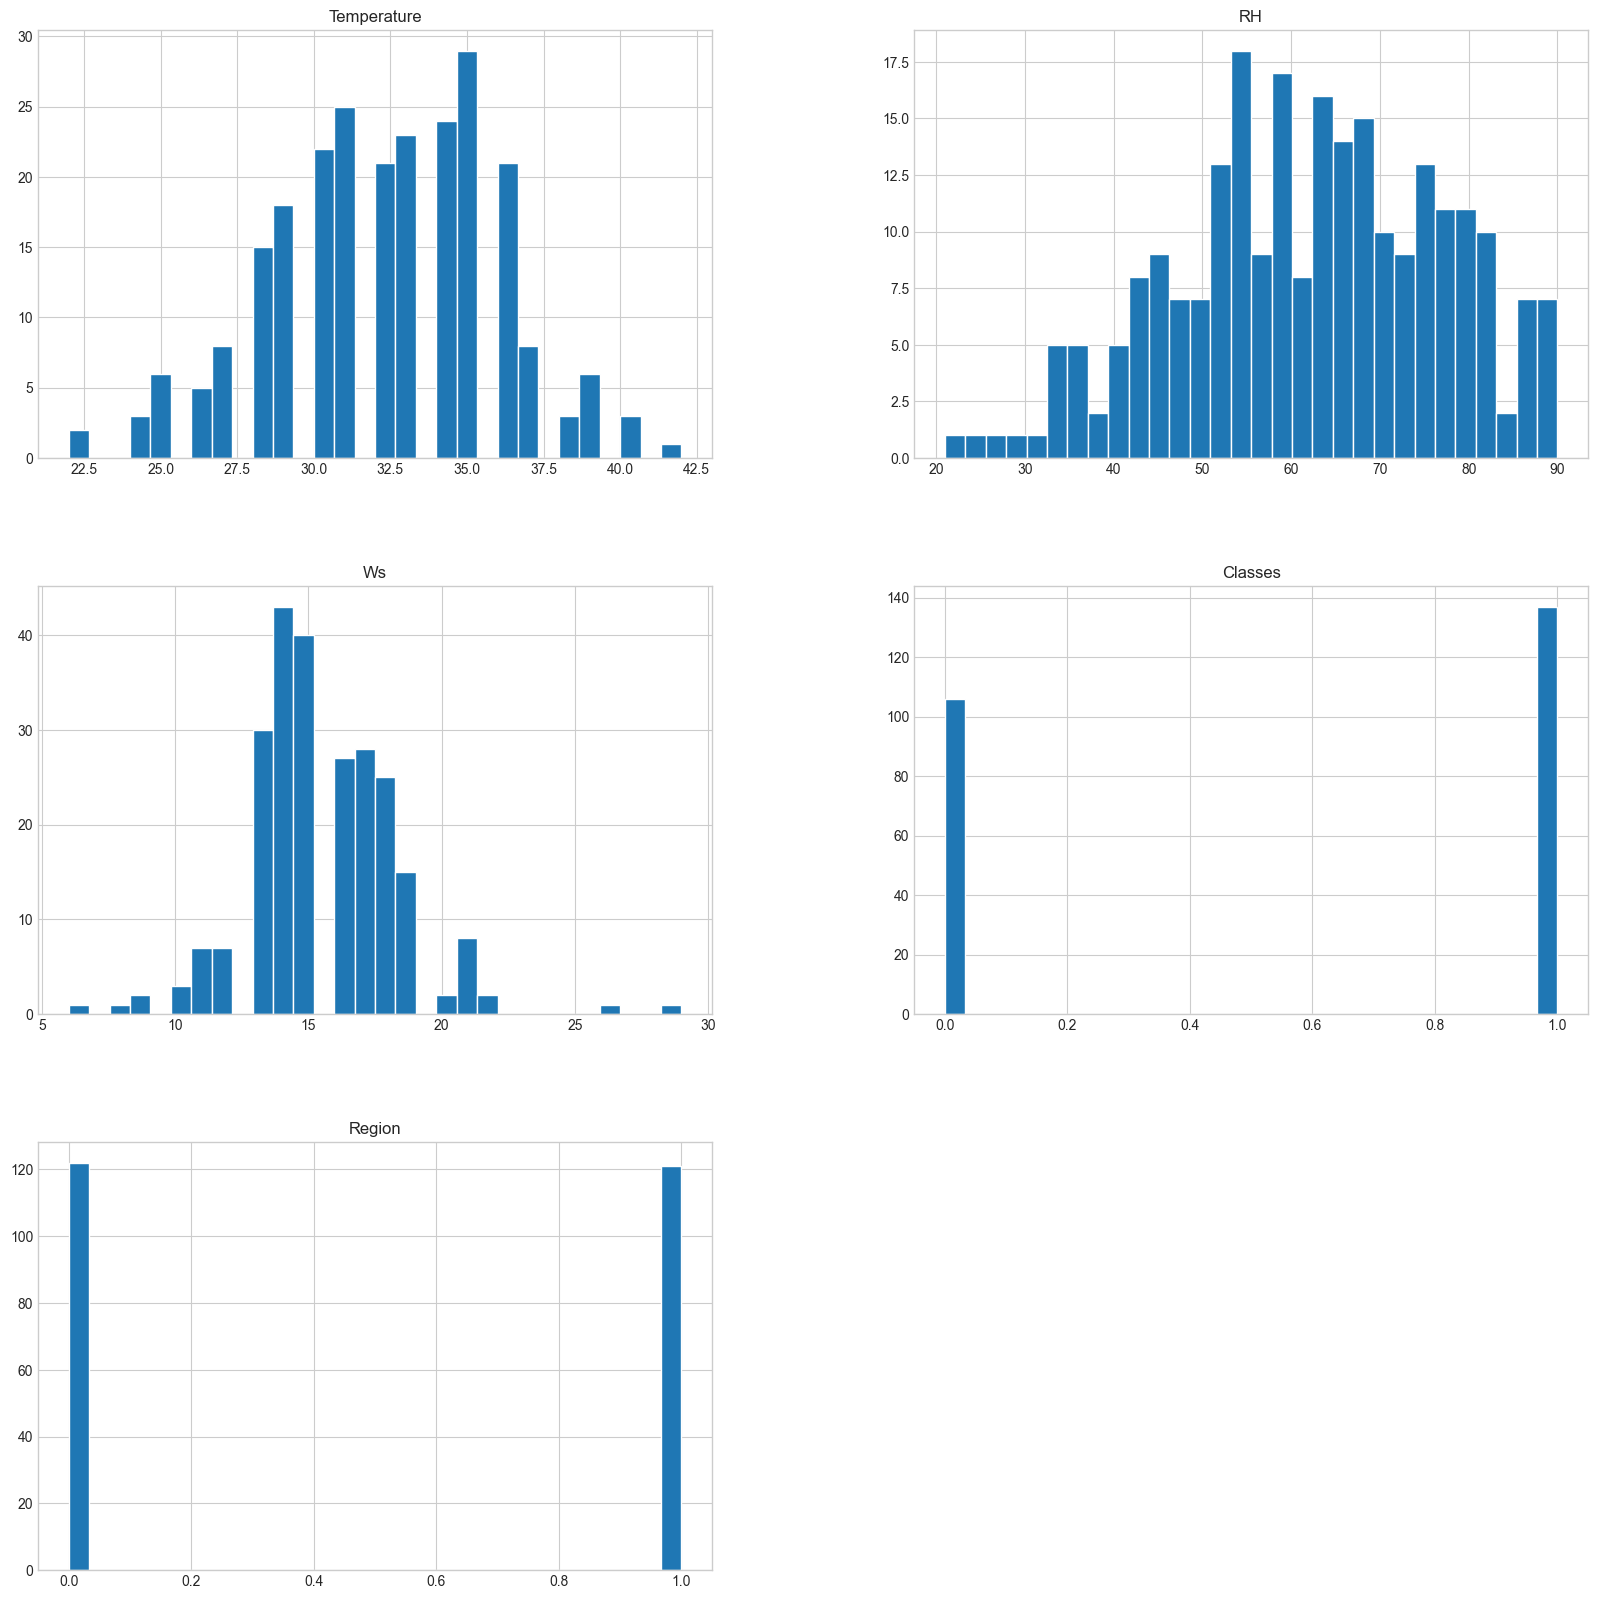

In [298]:
# Plot histograms for all features
plt.style.use('seaborn-v0_8-whitegrid')
df.hist(bins = 30, figsize=(20,20))
plt.show()

### 4.5. Pie Chart for 'Classes' Distribution

In [299]:
# Calculate the percentage of each class
percentage = df['Classes'].value_counts(normalize=True)*100

### 4.6. Plotting the Pie Chart

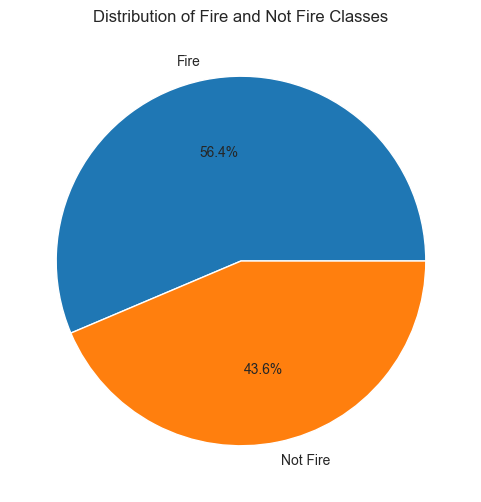

In [300]:
# Plot the pie chart
classlabels=['Fire','Not Fire']
plt.figure(figsize=(6,6))
plt.pie(percentage,labels=classlabels,autopct='%1.1f%%')
plt.title('Distribution of Fire and Not Fire Classes')
plt.show()

### 4.7. Correlation Analysis

In [301]:
# Calculate the correlation matrix
df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


In [302]:
# Correlation of 'Classes' with other features
df.corr()['Classes'].sort_values(ascending=False)

Classes        1.000000
FFMC           0.769492
ISI            0.735197
FWI            0.719216
BUI            0.586639
DMC            0.585658
Temperature    0.516015
DC             0.511123
Region         0.162347
Ws            -0.069964
Rain          -0.379097
RH            -0.432161
Name: Classes, dtype: float64

In [303]:
# Correlation of 'FWI' with other features
df.corr()['FWI'].sort_values(ascending=False)

FWI            1.000000
ISI            0.922895
DMC            0.875864
BUI            0.857973
DC             0.739521
Classes        0.719216
FFMC           0.691132
Temperature    0.566670
Region         0.197102
Ws             0.032368
Rain          -0.324422
RH            -0.580957
Name: FWI, dtype: float64

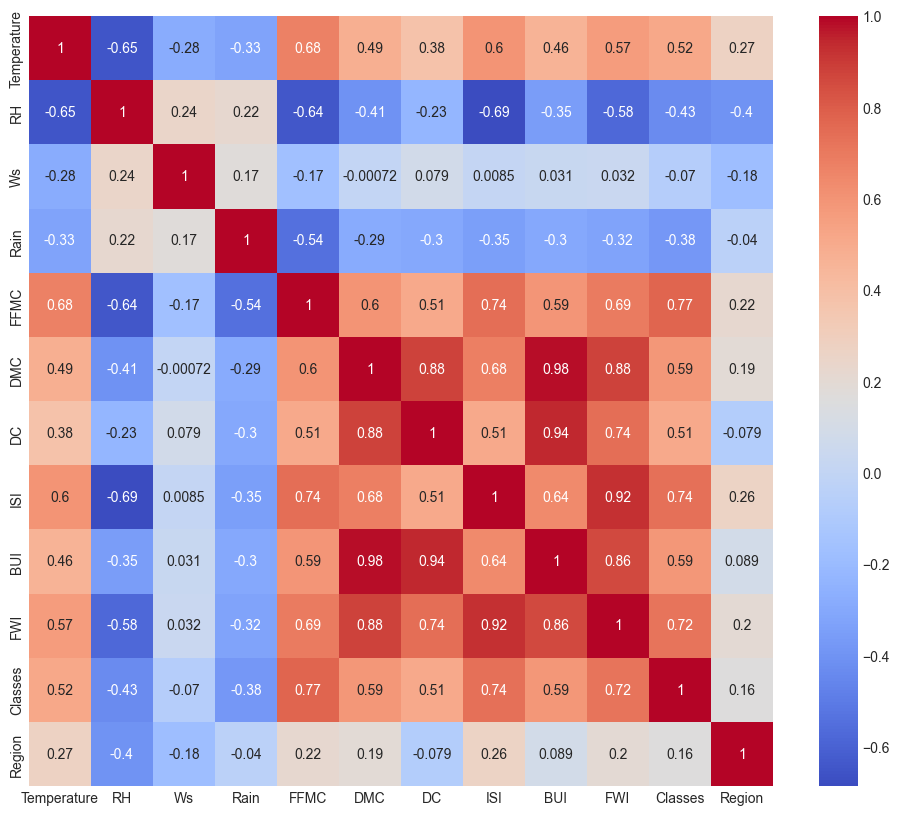

In [304]:
# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

### 4.8. Box Plot for FWI

A box plot helps us visualize the distribution of the Fire Weather Index (FWI) and identify outliers. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution.

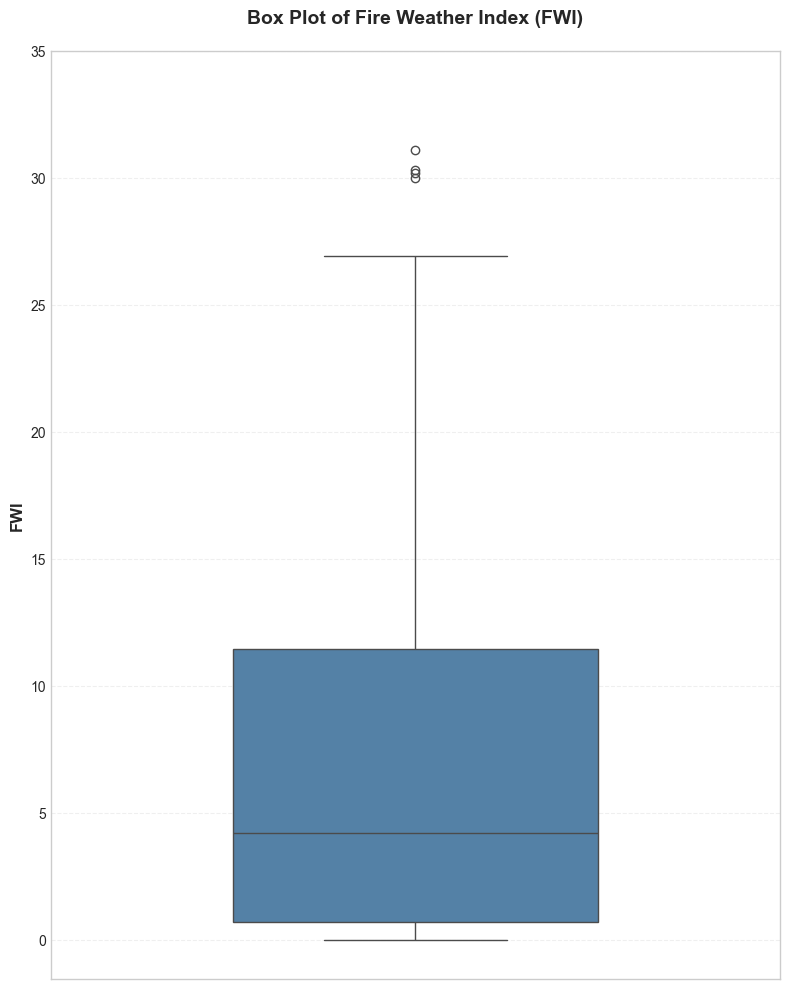

In [305]:
# Set up the figure size for better visibility
plt.figure(figsize=(8, 10))

# Convert FWI column to numeric type to handle any string values
fwi_numeric = pd.to_numeric(df['FWI'], errors='coerce')

# Create the vertical box plot with custom styling
sns.boxplot(y=fwi_numeric, color='steelblue', width=0.5)

# Add title and labels
plt.title('Box Plot of Fire Weather Index (FWI)', fontsize=14, weight='bold', pad=20)
plt.ylabel('FWI', fontsize=12, weight='bold')

# Set y-axis ticks at intervals of 5 to prevent overlapping numbers
y_max = fwi_numeric.max()
plt.yticks(np.arange(0, y_max + 5, 5), fontsize=10)

# Add subtle gridlines for easier reading
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()
plt.show()

In [306]:
# Display the first few rows of the original DataFrame
df_original.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [307]:
# Display the first few rows of the modified DataFrame
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0,0
4,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0,0


### 4.9. Bar Plot for Monthly Fire Analysis

In [308]:
# Get value counts of 'Classes' in the original DataFrame
df_original['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [309]:
# Encode 'Classes' in the original DataFrame
df_original['Classes']=np.where(df_original['Classes'].str.contains('not fire'),'not fire','fire')

In [310]:
# Get value counts of the encoded 'Classes' in the original DataFrame
df_original['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

### 4.10. Monthly Fire Analysis by Region

Text(0.5, 1.0, 'Fire Analysis of Sidi-Bel Abbes Region')

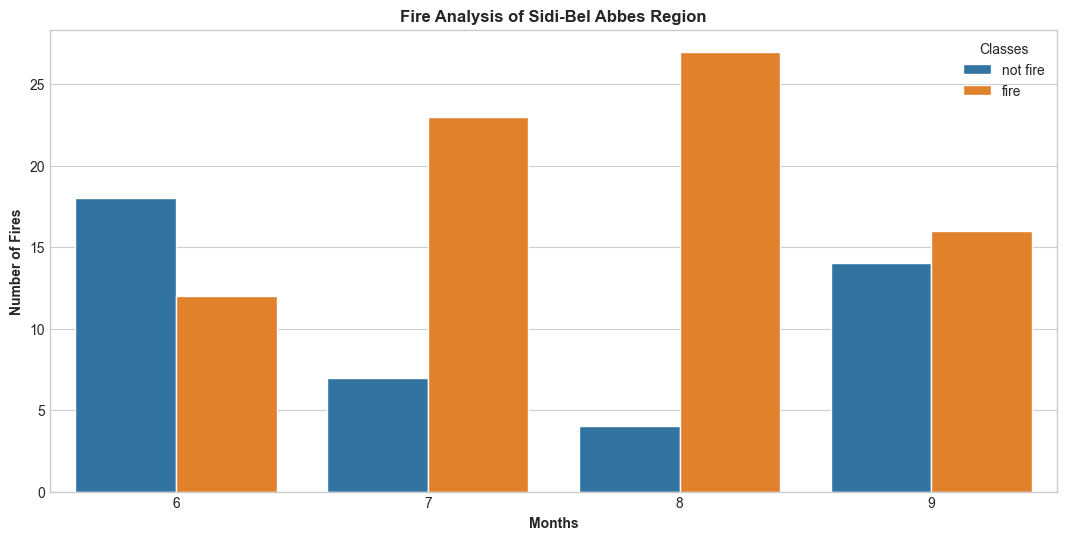

In [311]:
# Monthly fire analysis for Sidi-Bel Abbes Region
dftemp=df_original.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Sidi-Bel Abbes Region",weight='bold')

Text(0.5, 1.0, 'Fire Analysis of Bejaia Region')

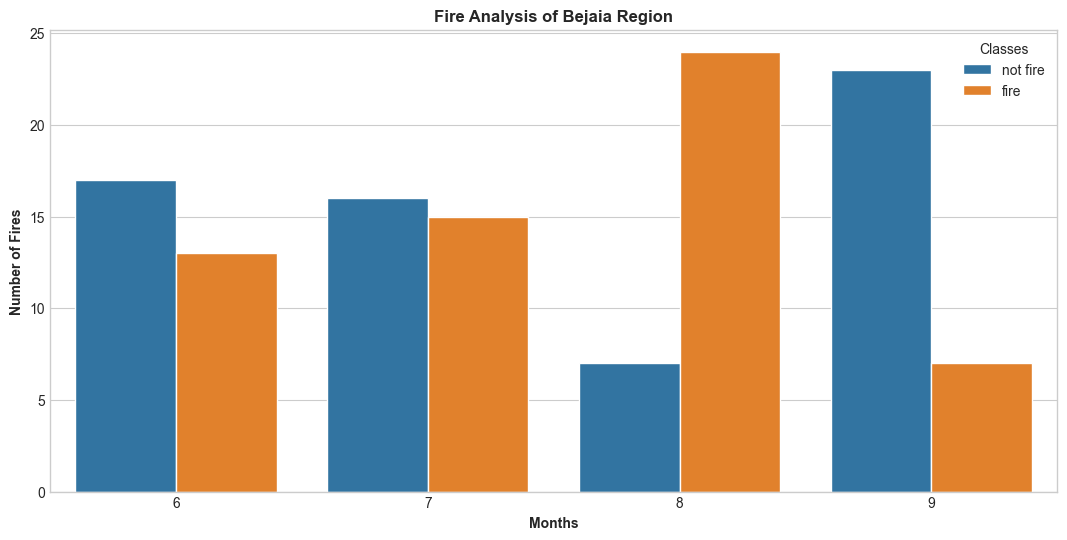

In [312]:
# Monthly fire analysis for Bejaia Region
dftemp=df_original.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)
plt.ylabel('Number of Fires',weight='bold')
plt.xlabel('Months',weight='bold')
plt.title("Fire Analysis of Bejaia Region",weight='bold')

<a id="observations-from-eda"></a>
## 5. Observations from EDA

- August and September have the most forest fires in both regions.
- The majority of fires occur in June, July, and August.
- September has the fewest fires.

<a id="model-preparation-and-training"></a>
## 6. Model Preparation

In [313]:
df_Model = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [314]:
df_Model.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [315]:
df_Model.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

### 6.1. Drop Month, Day, and Year Columns

In [316]:
df_Model.drop(['month','day','year'],axis = 1,inplace=True)

In [317]:
df_Model.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [318]:
df_Model.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='str')

In [319]:
df_Model['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

### 6.2. Encode the Target Classes

In [320]:
df_Model['Classes'] = np.where(df_Model['Classes'].str.contains("not fire"),0,1)

In [321]:
df_Model.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [322]:
df_Model['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

### 6.3. Independent and Dependent Features

In [323]:
X = df_Model.drop('FWI',axis=1)
y = df_Model['FWI']

In [324]:
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [325]:
y

0      0.5
1      0.4
2      0.1
3      0.0
4      0.5
      ... 
238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, Length: 243, dtype: float64

### 6.4. Train Test Split

In [326]:
from sklearn.model_selection import train_test_split

In [327]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [328]:
X_train.shape,X_test.shape,

((182, 11), (61, 11))

In [329]:
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


### 6.5. Check Multicollinearity Before Model Fitting

Text(0.5, 1.0, 'Correlation Heatmap of Training Features')

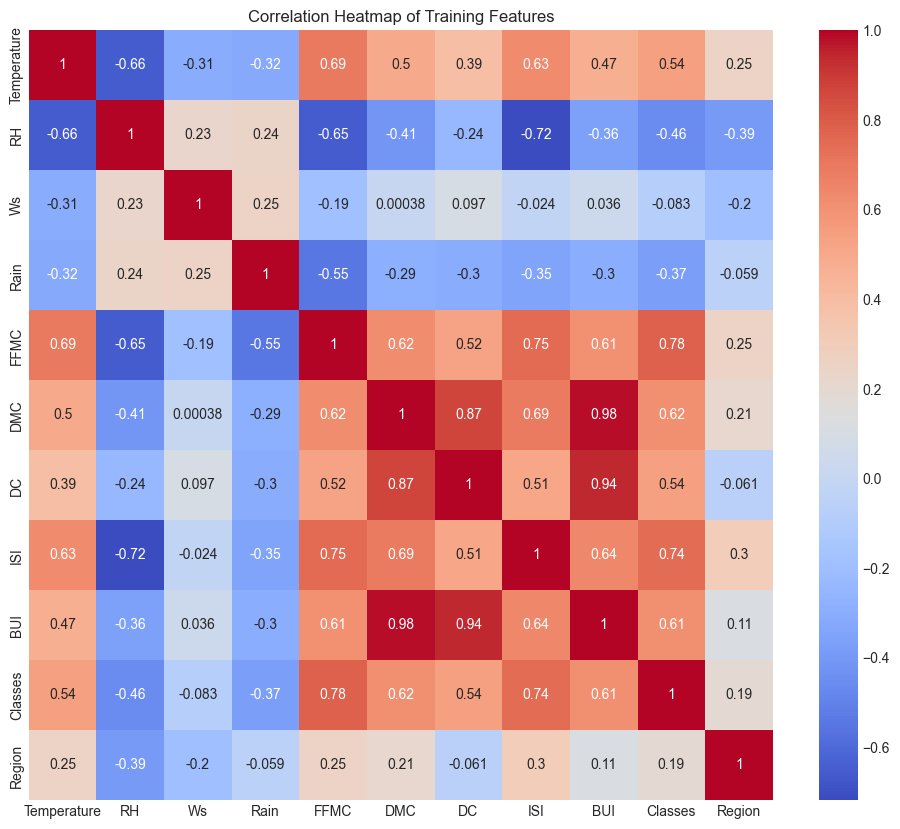

In [330]:
plt.figure(figsize=(12, 10))
corr = X_train.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Training Features')

### 6.6. Feature Selection based on Correlation

To prevent multicollinearity issues in regression models, we should identify and remove highly correlated independent features. The function below detects features that have a correlation coefficient higher than a specified threshold.

In [331]:
def correlation(dataset, threshold):
    """
    Identifies features that are highly correlated with each other.
    Highly correlated features can lead to multicollinearity issues.
    
    Args:
    dataset (pd.DataFrame): Training dataset.
    threshold (float): Absolute correlation threshold above which a feature should be dropped.
    
    Returns:
    set: Names of the columns that exceed the threshold.
    """
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [332]:
corr_features = correlation(X_train, 0.85)

In [333]:
## drop features when correlation is more than 0.85 
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)
X_train.shape,X_test.shape

((182, 9), (61, 9))

### 6.7. Feature Scaling Or Standardization

In [334]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.62963326,
        -1.10431526, -0.98907071],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.93058524,
        -1.10431526,  1.01105006],
       [ 2.13311985, -2.08870172, -0.21905398, ...,  2.7271388 ,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ..., -1.06948615,
        -1.10431526, -0.98907071],
       [ 0.50986767, -0.21870454,  0.16063958, ...,  0.5973248 ,
         0.90553851,  1.01105006],
       [-0.57230045,  0.98343651,  2.05910739, ..., -0.86113478,
        -1.10431526, -0.98907071]], shape=(182, 9))

### 6.8. Box Plots To understand Effect Of Standard Scaler

Text(0.5, 1.0, 'X_train After Scaling')

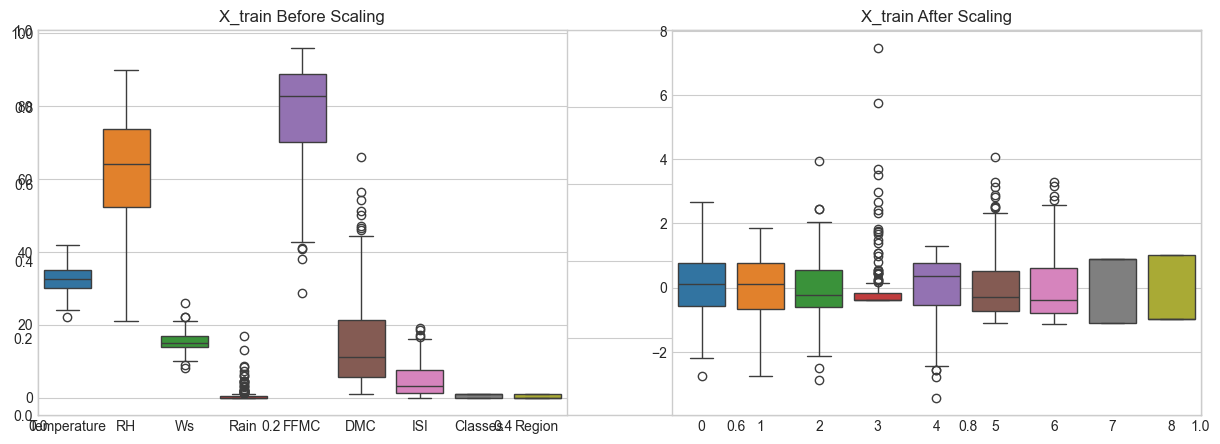

In [336]:
plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('X_train Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('X_train After Scaling')

<a id="linear-regression-model"></a>
## 7. Model Training and Evaluation

### 7.1. Linear Regression Model

In [ ]:
# Import Linear Regression from scikit-learn
from sklearn.linear_model import LinearRegression

In [ ]:
# Import metrics for evaluating regression models
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Initialize the Linear Regression model
linreg = LinearRegression()

# Fit the model on the scaled training data
linreg.fit(X_train_scaled,y_train)

# Predict the target classes on the scaled test data
y_pred = linreg.predict(X_test_scaled)

In [ ]:
# Calculate performance metrics
mae = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R^2 Score: {r2}')

Mean Absolute Error: 0.6742766873791582
R^2 Score: 0.9847657384266951


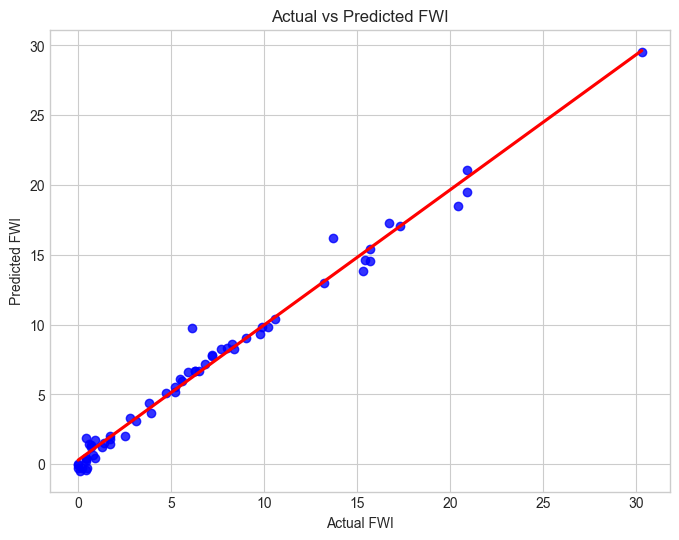

In [344]:
plt.figure(figsize=(8,6))

# Plot the scatter plot alongside the best-fit regression line
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI')
plt.show()

### 7.2. Lasso Regression model

In [ ]:
# Import Lasso Regression model and metrics
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Initialize the Lasso Regression model
lasso=Lasso()

# Fit the model on the scaled training data
lasso.fit(X_train_scaled,y_train)

# Predict the target variables on the scaled test data
y_pred=lasso.predict(X_test_scaled)

In [ ]:
# Calculate mean absolute error and coefficient of determination (R^2)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.1331759949144087
R2 Score 0.9492020263112388


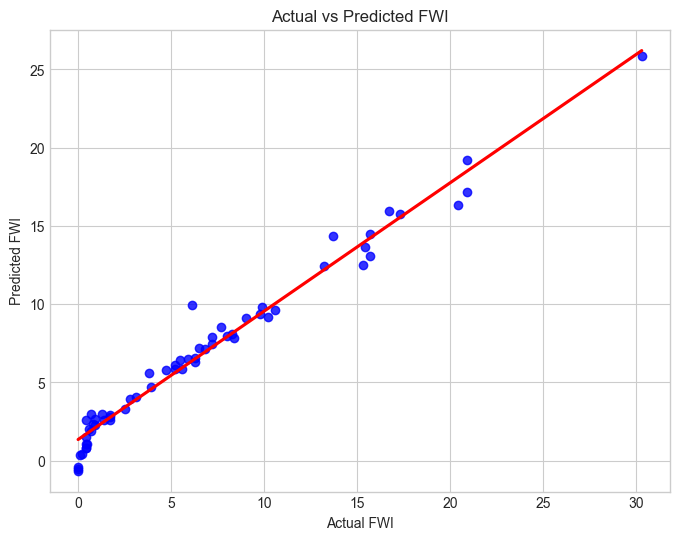

In [ ]:
# Set figure size for the plot
plt.figure(figsize=(8,6))

# Plot the scatter plot alongside the best-fit regression line for Lasso model
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (Lasso Regression)')
plt.show()

### 7.3. Cross Validated Lasso Regression model

In [ ]:
# Import LassoCV for cross validation
from sklearn.linear_model import LassoCV

# Initialize the model with 5 cross-validation folds
lassocv=LassoCV(cv=5)

# Fit the LassoCV model
lassocv.fit(X_train_scaled,y_train)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:
# Display the optimal alpha value chosen by cross-validation
lassocv.alpha_

np.float64(0.06582808719529475)

In [ ]:
# Display all the alpha values tested during cross-validation
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039

In [ ]:
# Display the Mean Squared Error (MSE) path for each fold during cross-validation
lassocv.mse_path_

array([[54.04680834, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139504, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.2013182 , 14.9991189 ,  9.9

In [ ]:
# Predict on the scaled test data
y_pred=lassocv.predict(X_test_scaled)

In [ ]:
# Calculate evaluation metrics based on the predicted test output
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.6358894638564663
R2 Score 0.9814406737205228


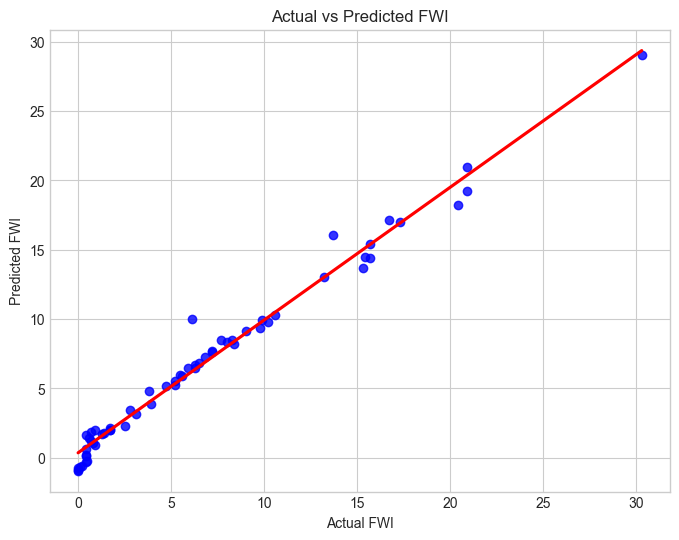

In [ ]:
# Plot the scatter plot alongside the best-fit regression line for LassoCV model
plt.figure(figsize=(8,6))
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (LassoCV Regression)')
plt.show()

### 7.4. Ridge Regression model

In [ ]:
# Import Ridge regression model and necessary statistics metrics
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# Initialize, fit on training data, and predict using the test data
ridge=Ridge()
ridge.fit(X_train_scaled,y_train)
y_pred=ridge.predict(X_test_scaled)

In [ ]:
# Evaluate Ridge regression metrics
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.5642305340105691
R2 Score 0.9842993364555513


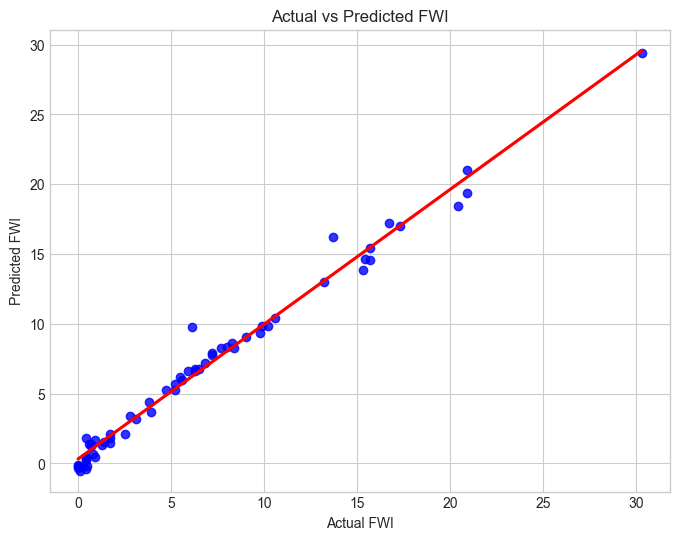

In [ ]:
# Set figure size
plt.figure(figsize=(8,6))

# Plot the scatter plot alongside the best-fit regression line for Ridge model
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (Ridge)')
plt.show()

### 7.5. Cross Validated Ridge Regression model

In [ ]:
# Import RidgeCV for cross validation model
from sklearn.linear_model import RidgeCV

In [ ]:
# Initialize RidgeCV model with 5 cross-validation folds, fit, and predict
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled,y_train)
y_pred=ridgecv.predict(X_test_scaled)

In [ ]:
# Evaluate performance for RidgeCV prediction outputs
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.5642305340105691
R2 Score 0.9842993364555513


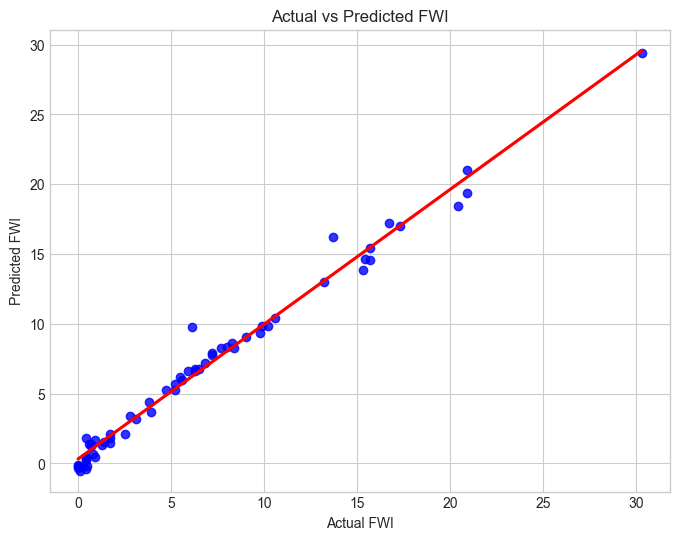

In [ ]:
# Plot the scatter plot alongside the best-fit regression line for RidgeCV model
plt.figure(figsize=(8,6))

sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (RidgeCV Regression)')
plt.show()

In [ ]:
# Display the parameters used by the RidgeCV model
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

### 7.6. ElasticNet Regression model

In [ ]:
# Import ElasticNet model and metrics
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [ ]:
# Initialize, fit on training data, and predict using the ElasticNet model
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)

In [ ]:
# Evaluate ElasticNet regression performance
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 1.8822353634895996
R2 Score 0.8753460589519704


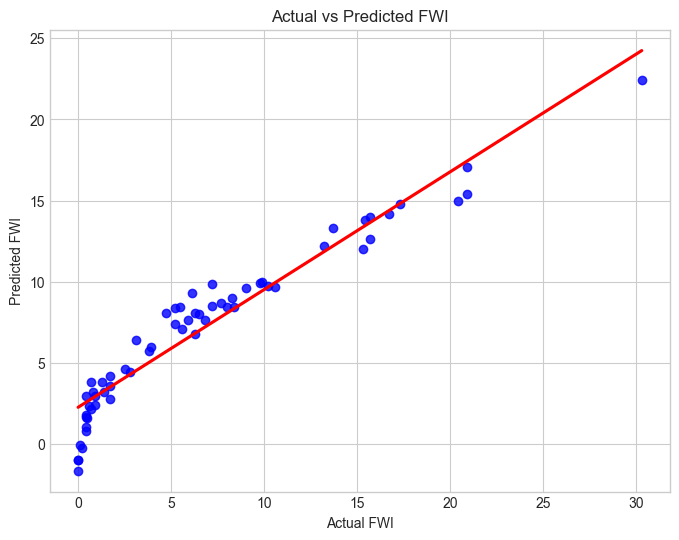

In [ ]:
# Set plot size
plt.figure(figsize=(8,6))

# Plot the scatter plot alongside the best-fit regression line for ElasticNet model
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (ElasticNet Regression)')
plt.show()

### 7.7. Cross Validated ElasticNet Regression model

In [ ]:
# Import cross-validated ElasticNet model
from sklearn.linear_model import ElasticNetCV

In [ ]:
# Initialize the ElasticNetCV model with 5 folds, fit the model and predict output
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled,y_train)
y_pred=elasticcv.predict(X_test_scaled)

In [ ]:
# Validate the accuracy of ElasticNetCV
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)

print("Mean absolute error", mae)
print("R2 Score", score)

Mean absolute error 0.6575946731430902
R2 Score 0.9814217587854941


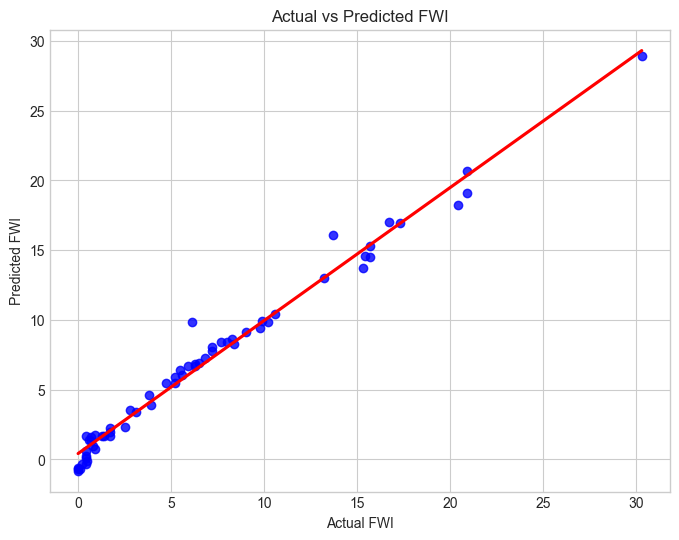

In [ ]:
# Create final visual representation of Actual vs Predicted for ElasticNetCV
plt.figure(figsize=(8,6))

# Plot the scatter plot alongside the best-fit regression line
sns.regplot(x=y_test, y=y_pred, ci=None, color="blue", line_kws={"color": "red"})

plt.xlabel('Actual FWI')
plt.ylabel('Predicted FWI')
plt.title('Actual vs Predicted FWI (ElasticNetCV Regression)')
plt.show()

In [ ]:
# Output all the alpha parameters tested by Cross Validated ElasticNet model
elasticcv.alphas_

array([14.11706004, 13.16561744, 12.27829889, 11.45078264, 10.67903821,
        9.95930678,  9.28808283,  8.66209714,  8.07830078,  7.53385034,
        7.02609405,  6.55255882,  6.11093829,  5.6990815 ,  5.31498248,
        4.95677045,  4.62270071,  4.31114616,  4.02058933,  3.74961507,
        3.49690356,  3.26122397,  3.04142839,  2.83644629,  2.64527931,
        2.46699633,  2.30072904,  2.1456676 ,  2.00105679,  1.86619226,
        1.74041714,  1.62311885,  1.51372607,  1.411706  ,  1.31656174,
        1.22782989,  1.14507826,  1.06790382,  0.99593068,  0.92880828,
        0.86620971,  0.80783008,  0.75338503,  0.7026094 ,  0.65525588,
        0.61109383,  0.56990815,  0.53149825,  0.49567705,  0.46227007,
        0.43111462,  0.40205893,  0.37496151,  0.34969036,  0.3261224 ,
        0.30414284,  0.28364463,  0.26452793,  0.24669963,  0.2300729 ,
        0.21456676,  0.20010568,  0.18661923,  0.17404171,  0.16231189,
        0.15137261,  0.1411706 ,  0.13165617,  0.12278299,  0.11